<a href="https://colab.research.google.com/github/na00camargom/IA_Bootcamp/blob/main/Copia_de_S4_C1_LAB_Logistic_Regression_Part_1_temp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2 align="center"> Logistic Regression </h2>

## **Actividad 2**


---


## **Balance de clases**
El balance de las clases se refiere a la ***distribución*** de las clases en un conjunto de datos de clasificación.

Un conjunto de datos está ***balanceado ***cuando las diferentes clases tienen aproximadamente el mismo número de muestras. Si una clase tiene significativamente más ejemplos que otra, se dice que el conjunto de datos está ***desbalanceado.***

Por ejemplo, si estás clasificando si un examen fue aprobado o no, y el 90% de los estudiantes aprobaron mientras solo el 10% fallaron, el conjunto de datos está desbalanceado. Un modelo entrenado en un conjunto de datos desbalanceado tiende a estar sesgado hacia la clase mayoritaria (en este caso, los aprobados), lo que puede llevar a un mal rendimiento en la predicción de la clase minoritaria (los que fallaron).

### **¿Cómo manejarlo?**

**Aumentar la clase minoritaria (Oversampling):**

* SMOTE (Synthetic Minority Over-sampling Technique): Genera ejemplos sintéticos de la clase minoritaria combinando características de los datos existentes.
* Random Oversampling: Duplica aleatoriamente ejemplos de la clase minoritaria hasta que ambas clases tengan tamaños similares.

**Reducir la clase mayoritaria (Undersampling):**

* Random Undersampling: Reduce el tamaño de la clase mayoritaria eliminando ejemplos aleatoriamente hasta igualar el tamaño de la clase minoritaria.

**Recolección de más datos**

**Usar algoritmos adaptados a datos desbalanceados**

* Balanced Random Forest o Class-balanced loss functions

Data set:

* **Test_1:** Puntuación en el primer examen.
* **Test_2:** Puntuación en el segundo examen.
* **Results:** Resultado del examen (0 = Fallido, 1 = Aprobado).

### **Actividad 1. Cargue librerías y datos**
------

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.style.use("dark_background")
%matplotlib inline

from google.colab import drive
import os
import math

In [3]:
from pylab import rcParams
rcParams['figure.figsize'] = 5,3

### *Tareas A1*

* Cargue los datos 'Classification_Tests.csv' desde su carpeta de drive
* Muestre las 5 pirmeras filas

In [4]:
# Cargue los datos, imprima las primeras filas
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Colab Notebooks/Bootcamp - IA/Modulo 1/DataSets')
print(os.listdir())

Mounted at /content/drive
['Classification_Tests.csv']


In [5]:
data = pd.read_csv("Classification_Tests.csv")
data.head(5)

,Test_1,Test_2,Results
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


### **Actividad 2. Descripción del data set**
------

### *Tareas A2*

* Describa los datos (Atributos, registros, rangos, distribuciones)
* ¿Debe aplicar alguna técnica de limpieza?



In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Test_1   100 non-null    float64
 1   Test_2   100 non-null    float64
 2   Results  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [7]:
data.describe()

,Test_1,Test_2,Results
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000


Dado que la media en la columna de Results es 0.6, hay una proporción 6 a 4 entre una etiqueta y la otra, que es una relación aceptable entre los datos.
Los rangos son:
* (30.058822 - 99.827858) para el Test 1
* (30.603263 - 98.869436) para el Test 2

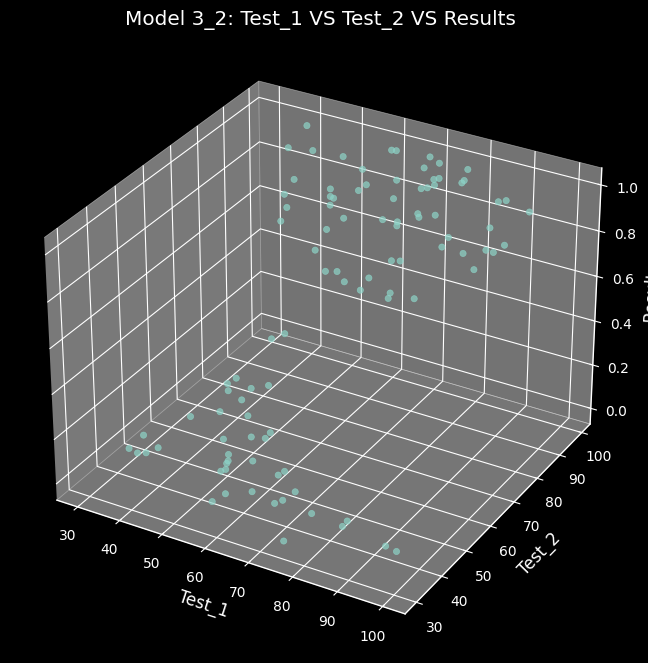

In [14]:
fig = plt.figure(figsize=(8, 13))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['Test_1'],data['Test_2'],data['Results'], alpha = 0.7)
ax.set_title('Model 3_2: Test_1 VS Test_2 VS Results')
ax.set_xlabel('Test_1')
ax.set_ylabel('Test_2')
ax.set_zlabel('Results')

plt.show()

### *Tareas A2*

* Realice un diagrama de barras al target (concluya respecto al balance de las clases)

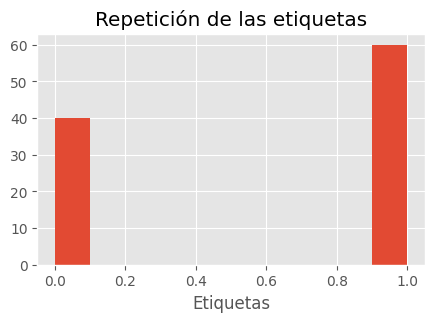

In [9]:
plt.hist(data['Results'])
plt.title("Repetición de las etiquetas")
plt.xlabel("Etiquetas")
# plt.ylabel("")

plt.show()

### **Actividad 3: Construya un diagrama de las clases de data set**
---

### *Tareas A3*

Las siguientes líneas de código grafican el diagrama de dispersión (scatter) de los datos de los que no aprobaron

* Ingresa la línea de código para que gráfique la clase que si aprobó con un triangulo verde
*  Complete los títulos de la gra´fica y los ejes

In [1]:
target = data['Results']

plt.figure(figsize=(8,5))
plt.scatter(data['Test_1'][target == 0], data['Test_2'][target== 0], alpha=0.5, label='No aprobó (0)', marker='X', color='red')
plt.scatter(data['Test_1'][target == 1], data['Test_2'][target== 1], alpha=0.5, label='Aprobó (1)', marker='o', color='blue')

plt.title('Qué título tiene esta grafica')
plt.xlabel('Calificación del Test 1')
plt.ylabel('Calificación del Test 2')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'data' is not defined

### **Actividad 4: Defina una función para calcular la función sigmoid**
---

$$ h(z) = \frac{1}{1+e^{-z}}$$

### *Tareas A4*

En clases pasadas desarrollamos la función de para en cálculo de la sigmoid

* Copia la función y grafica en un rango de -10 a 10
* Describa la función sigmoid
* Cuál es el rango de la función sigmoid? Es decir en qué valores existe la función?

In [10]:
def sigm(probs):
  odds = list()
  for i in probs:
    odds.append(1/(1+math.exp(-i)))

  plt.figure(figsize=(9,5))
  plt.plot(probs, odds)
  plt.xlabel("Probabilidades")
  plt.ylabel("Sigmoide")
  plt.title("Funcion Sigmoide")
  plt.show()

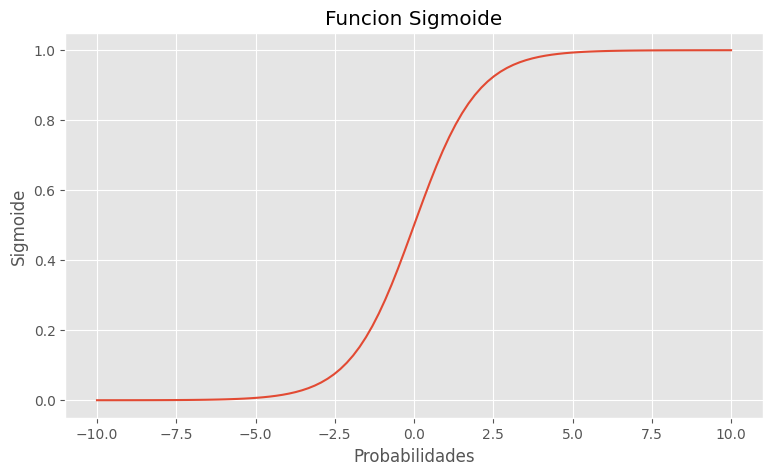

In [11]:
probs = np.linspace(-10, 10, 100)
sigm(probs)

La función existe entre 0 y 1, y describe una curva sigmoidal.

### Actividad 5: Cálculo de la función de costos $J(\theta)$
---

El objetivo de la regresión logística es minimizar la función de costo

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [ y^{(i)}log(h_{\theta}(x^{(i)})) + (1 - y^{(i)})log(1 - (h_{\theta}(x^{(i)}))]$$

donde el gradiente de la función de costo está dado por

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})x_j^{(i)}$$

### *Tareas A5*

* Contruya una función para calcular la función de costo
* Construya una gráfica con plot(h,y) para graficar la función de costo.
1. Genere un vector de datos con todos los posibles valores de h
2. Grafique un plot cuando  y = 0
3. Grafique un plot cuando  y = 1

* Concluya

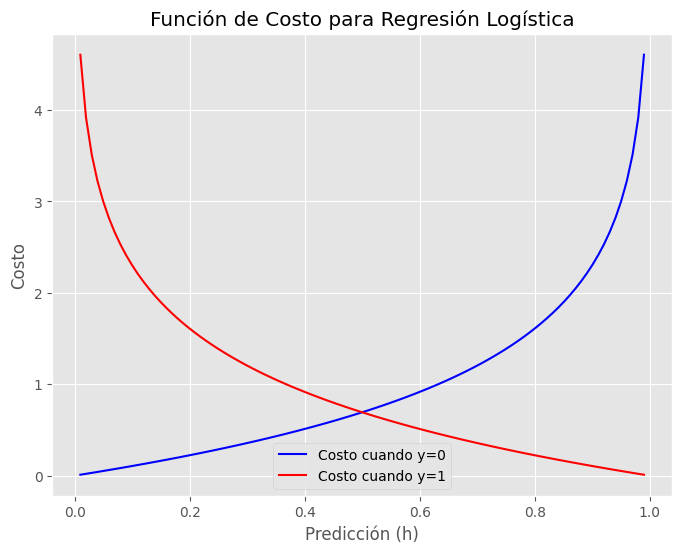

In [12]:
# Definir la función de costo para logistic regression
def cost_function(h, y):
    return -y * np.log(h) - (1 - y) * np.log(1 - h)

# Crear valores de h (predicción) desde casi 0 hasta casi 1
h_values = np.linspace(0.01, 0.99, 100)

# Calcular el costo para y=0 y y=1
cost_for_y0 = cost_function(h_values, 0)
cost_for_y1 = cost_function(h_values, 1)

# Graficar las funciones de costo
plt.figure(figsize=(8, 6))
plt.plot(h_values, cost_for_y0, label='Costo cuando y=0', color='blue')
plt.plot(h_values, cost_for_y1, label='Costo cuando y=1', color='red')
plt.xlabel('Predicción (h)')
plt.ylabel('Costo')
plt.title('Función de Costo para Regresión Logística')
plt.legend()